# Automated LLM Evaluation Pipeline (Local / GGUF)

*Trimester: T3 2025*  
*Author: Matthew O'Donnell*

This notebook is the **orchestration layer** for an end-to-end evaluation pipeline for a *University Feedback LLM* (an LLM that grades student submissions against a rubric and generates feedback).  
It assumes the heavy lifting lives in the `evaluation/` package (data loading, inference, metrics, DeepEval wrapper, reporting).

### What this notebook does
1. **Load config + data** and initialise a `ModelManager`.
2. **Optionally generate “gold” feedback** (synthetic ground-truth text feedback) where the dataset is missing human feedback.
3. **Run the subject model** (the model-under-test) to predict rubric scores + feedback.
4. **Compute quantitative metrics** (correlations, error metrics, BERTScore, etc.).
5. **Gatekeeper checks** (citation recall) for evidence-grounded feedback.
6. **LLM-as-a-Judge scoring via DeepEval** (quality attributes such as relevance, accuracy, safety, actionability, rubric alignment).
7. **Save a summary CSV + print/readable explanation** and **generate plots**.
8. **Optional meta-analysis** by a larger model to produce an executive summary.
9. **Cleanup** (unload models to free RAM/VRAM).

### How to reuse this notebook on a new project
- **Change configuration** (paths + model repos) in `evaluation/config_loader.py`.
- Ensure your input data has the required columns (documented in `load_data()`).
- Check other py's for column accuracy.
- Run cells top-to-bottom; each stage appends columns to `df` and/or writes artifacts to disk.

### Configuration keys (typical)
Your `config` should usually contain:
- `data_path`: path to TSV/CSV input dataset
- `output_dir`: directory for saved artifacts (CSVs, plots, reports)
- `gold_model`, `subject_model`, `judge_model`, `meta_analysis_model`: model specs (repo/path, backend, quantisation, etc.)

> Tip: Keep your config as the single source of truth. The more “magic constants” you remove from the notebook, the easier this becomes to share across teammates.

### Outputs you should expect
- `metrics_summary.csv` (single-row summary used by the explainer + meta-analysis)
- one or more “long-form” results files (depends on modules)
- plots saved in `output_dir`
- printed stage logs (or written logs if you redirect logging)

### Troubleshooting (common)
- **Out of memory**: run `cleanup(manager)` more aggressively (after big models), reduce batch sizes in inference modules, or skip meta-analysis.
- **Noisy model logs**: set `TRANSFORMERS_VERBOSITY=error` and/or tighten logging config in the first code cell.
- **Missing columns**: check your dataset schema vs what the modules expect (especially before DeepEval / metrics stages).

### Environment Setup
To run this pipeline, you will need to refer to `Evaluation_Environment_Setup_Guide.md` (aaie-model-lab/Evaluation/Evaluation Pipeline/version_T3_2025/docs). As outlined in the .md file, you will also need to install dependencies from `requirements.txt` (aaie-model-lab/Evaluation/Evaluation Pipeline/version_T3_2025).

### Models used
- Ground truth / gold-feedback generator: **Llama 3.1 8B Instruct** (GGUF)  
[https://huggingface.co/bartowski/Meta-Llama-3.1-8B-Instruct-GGUF]  

- Subject model being evaluated: **Llama 3.2 3B Instruct** (GGUF)  
[https://huggingface.co/unsloth/Llama-3.2-3B-Instruct-GGUF] 

- Judge model for DeepEval: **Qwen 2.5 7B** (GGUF) via a wrapper  
[https://huggingface.co/unsloth/gpt-oss-20b-GGUF] 

- Meta analysis model for meta results analysis: **GPT-OSS-20B** (GGUF)  
[https://huggingface.co/unsloth/Qwen2.5-VL-7B-Instruct-GGUF]  

Each of these models also have system prompts. Please see respective files for further information.

### Dataset used

The dataset used for this is the DREsS_New dataset by Haneul Yoo, Jieun Han, So-Yeon Ahn, and Alice Oh. You will need to attain this dataset in order to run this pipeline as it is for reproduceable results. Note that I have contained concent for this, although I have not included the data here.

@inproceedings{yoo-etal-2025-dress,
    title = "{DRE}s{S}: Dataset for Rubric-based Essay Scoring on {EFL} Writing",
    author = "Yoo, Haneul  and
      Han, Jieun  and
      Ahn, So-Yeon  and
      Oh, Alice",
    editor = "Che, Wanxiang  and
      Nabende, Joyce  and
      Shutova, Ekaterina  and
      Pilehvar, Mohammad Taher",
    booktitle = "Proceedings of the 63rd Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)",
    month = jul,
    year = "2025",
    address = "Vienna, Austria",
    publisher = "Association for Computational Linguistics",
    url = "https://aclanthology.org/2025.acl-long.659/",
    doi = "10.18653/v1/2025.acl-long.659",
    pages = "13439--13454",
    ISBN = "979-8-89176-251-0",
}

### Pipeline workflow
This `main_evaluation.ipynb` notebook is the main executable file for this projects pipeline. It is advised to run this file within a jupyter-enabled IDE (VS Code etc).

## Step 1: Load py files and Libraries 
- Loads the project files from repository.
- Loads further required libraries.
- Enables logging.
- Loads projects configuration `config_loader.py` which details:
    - Data path (loading the dataset)
    - LLM Paths (load/download)
        - ground_truth_model
        - subject_model
        - judge_model
        - meta_analysis_model
    - Set parameters:
        - Sample size
        - Temperature
        - Max tokens
- Loads model_manager helper function from `model_manager.py`.  

- Files: `config_loader.py` & `model_manager.py`

In [1]:
import logging
import sys
from evaluation.config_loader import get_config, load_data
from evaluation.model_manager import ModelManager
from evaluation.gold_feedback import generate_gold_feedback_for_df
from evaluation.subject_model_inference import run_subject_model_inference
from evaluation.metrics import calculate_metrics
from evaluation.gatekeeper import apply_citation_recall
from evaluation.deepeval_wrapper import run_deepeval
from evaluation.visualization import generate_visualizations
from evaluation.cleanup import cleanup
from evaluation.results_explainer import explain_results
from evaluation.meta_analysis import perform_meta_analysis

# Configure logging to output informative messages
logging.basicConfig(level=logging.INFO)

# Load configuration and initialise model manager
config = get_config()
manager = ModelManager()
df = load_data(config)

if df is None:
    print("Warning: data could not be loaded. Please check config['data_path'].")
    sys.exit(1)


INFO:evaluation.config_loader:Loaded dataset with 400 rows.


## Stage 2: Generate Golden Feedback (optional)

**Goal:** ensure each row has a “gold / reference” feedback text so we can evaluate *generated* feedback against a baseline.

This stage is useful when:
- your dataset has rubric scores but **missing human-written feedback**, or
- you want a consistent reference style for early benchmarking.

**What happens:**
- `generate_gold_feedback_for_df(df, manager, config)` fills/creates a `gold_feedback` column (or equivalent),
  typically containing *one paragraph* aligned to the rubric and the student response.

**Inputs (typical):**
- `df` with student submission text + rubric labels (scores)
- `config['gold_model']` describing the model used to generate missing gold feedback

**Outputs:**
- `df` augmented with reference feedback columns, ready for later metrics such as BERTScore and judge-based evaluation.

**Notes for reuse:**
- Treat this as a *bootstrap step*. Once you collect real human feedback, you can skip it entirely.
- File: `gold_feedback.py`.

In [ ]:
try:
        df = generate_gold_feedback_for_df(df, manager, config)
except Exception as e:
        print(f"Warning: failed to generate gold feedback: {e}")

INFO:evaluation.gold_feedback:Starting Stage 1: Generating Clean Gold Feedback…


Generating Gold Feedback:   0%|          | 0/400 [00:00<?, ?it/s]INFO:evaluation.model_manager:Loading model: bartowski/Meta-Llama-3.1-8B-Instruct-GGUF (Meta-Llama-3.1-8B-Instruct-IQ2_M.gguf)…
llama_context: n_ctx_per_seq (8192) < n_ctx_train (131072) -- the full capacity of the model will not be utilized
ggml_metal_init: skipping kernel_get_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_set_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_c4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_1row              (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_l4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_bf16                  (not supported)
ggml_metal_init: skipping kern

## Stage 3: Subject Model Inference (model-under-test)

**Goal:** run the *subject model* (Llama 3.2 3B instruct) to produce:
- predicted rubric scores (Content / Organisation / Language), and
- generated feedback text intended for the student.

**What happens:**
- `run_subject_model_inference(df, manager, config)` loads the subject model (if needed) and writes predictions back into `df` as new columns (e.g., `pred_content`, `pred_organisation`, `pred_language`, `pred_feedback`).

**Why this is separated from metrics:**
- Inference is slow + expensive; keeping it isolated makes it easier to:
  - swap prompt versions,
  - cache outputs,
  - rerun metrics without re-inferencing.

**Notes for reuse:**
- If you change your prompt template, record the prompt version in `config` (e.g., `prompt_version`) and write it into outputs.
- If you do *few-shot*, keep the exemplars in a dedicated file so the notebook stays clean.

**Notes:**
- Model: `Five-shot Llama-3.2-3B-Instruct`
    - This model contains a five-shot system prompt due to the relative underperformance of zero-shot and few-shot approaches.
- File: `subject_model_inference.py`

In [ ]:
try:
        df = run_subject_model_inference(df, manager, config)
except Exception as e:
        print(f"Warning: failed during subject model inference: {e}")

INFO:evaluation.subject_model_inference:Starting Stage 2: Inference with the subject model…
Subject Model Inference:   0%|          | 0/400 [00:00<?, ?it/s]INFO:evaluation.model_manager:Unloading model: bartowski/Meta-Llama-3.1-8B-Instruct-GGUF/Meta-Llama-3.1-8B-Instruct-IQ2_M.gguf…
INFO:evaluation.model_manager:Loading model: unsloth/Llama-3.2-3B-Instruct-GGUF (Llama-3.2-3B-Instruct-Q4_K_M.gguf)…
llama_context: n_ctx_per_seq (8192) < n_ctx_train (131072) -- the full capacity of the model will not be utilized
ggml_metal_init: skipping kernel_get_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_set_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_c4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_1row              (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_l4                (no

## Stage 4: Quantitative Metrics (automatic scoring)

**Goal:** compute numeric measures of performance for:
- **rubric score prediction** (agreement with ground truth scores), and
- **feedback quality** (similarity to gold feedback, when available).

Common metric families here include:
- score agreement: Pearson/Spearman, MAE, Quadratic Weighted Kappa (QWK)
- text similarity: BERTScore, but may want to include ROUGE, BLEU (domain-dependent)
- future pipeline iterations may include distribution sanity checks: missingness, out-of-range scores, class imbalance etc.

**What happens:**
- `calculate_metrics(df)` returns:
  - an updated `df` (include per-row metrics like `bert_score_f1`), and
  - a `metrics` dict (summary scalars used for reporting).

**Notes for reuse:**
- Keep “per-row metrics” in the dataframe and “summary metrics” in the dict. This makes it trivial to plot distributions and also produce a compact summary CSV.
- File: `metrics.py`

In [ ]:
metrics = {}
try:
    df, metrics = calculate_metrics(df)
except Exception as e:
    print(f"Warning: failed to compute metrics: {e}")

INFO:evaluation.metrics:Calculating BERTScore…
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
INFO:evaluation.metrics:Metrics computed: {'content_pearson': np.float64(0.08397088266715017), 'content_spearman': np.float64(0.1287887475029257), 'content_mse': 1.905625, 'content_kappa': 0.061919061919061935, 'organization_pearson': np.float64(0.18496744616300387), 'organization_spearman': np.float64(0.2184437749192814), 'organization_mse': 1.945625, 'organization_kappa': 0.13190205684956413, 'language_pearson': np.float64(0.23916481586075325), 'language_spearman': np.float64(0.2634239670250909), 'language_mse': 1.27, 'language_kappa': 0.23201014794490327, 'total_pearson': np.float64(0.21684283777443675), 'total_spearman': np.float64(0.2655762667823402), 'total_mse':

## Stage 5: Gatekeeper Checks (Citation Recall)

**Goal:** verify evidence-grounding behaviours - for example, whether feedback that makes claims about the submission actually references the submission content.

This is a *safety + trust* check in an education setting, because ungrounded feedback can mislead students.

**What happens:**
- `apply_citation_recall(df)` computes a `citation_recall` column (typical name) per row.

**Notes for reuse:**
- If you later add RAG (retrieval - which you will need to), this stage is where you’d extend checks to include:
  - citation correctness (does cited evidence actually support the claim?)
  - coverage (are key claims supported?)
- File: `gatekeeper.py`

In [3]:
try:
    df = apply_citation_recall(df)
except Exception as e:
    print(f"Warning: failed to compute citation recall: {e}")

INFO:evaluation.gatekeeper:Average citation recall: 0.0798


## Stage 6: DeepEval / LLM-as-a-Judge Evaluation (qualitative attributes at scale)

**Goal:** score generated feedback on dimensions humans care about but are hard to capture with similarity metrics.

Typical dimensions used in this project:
- Relevance, Accuracy, Safety, Coherence
- Bias, Faithfulness (grounding), Justification
- Tone, Actionability, Rubric alignment

**What happens:**
- `run_deepeval(df, manager, config)` runs the judge model and writes per-row judge scores back into `df` and also write a results file.

**Notes for reuse:**
- Judge prompts are a product. Version them and store them alongside the code.
- If your judge model changes, expect distribution shifts in judge scores. Keep historical runs for comparability
- Note that when using Deepeval's G-Eval, you can create these custom metrics easily. Please see the respective file and look to the structure/format of each. You are not limited to these ten, so if you feel others are needed you can expand easily.
- File: `deepeval_wrapper.py`

In [4]:
try:
    df = run_deepeval(df, manager, config)
except Exception as e:
    print(f"Warning: failed to run DeepEval: {e}")

INFO:evaluation.deepeval_wrapper:DeepEval judge wrapper initialised.
INFO:evaluation.deepeval_wrapper:Starting DeepEval evaluation with the judge model…
DeepEval Evaluating:   0%|          | 0/400 [00:00<?, ?it/s]

Output()

INFO:evaluation.model_manager:Loading model: unsloth/Qwen2.5-VL-7B-Instruct-GGUF (Qwen2.5-VL-7B-Instruct-Q4_K_M.gguf)…


llama_context: n_ctx_per_seq (8192) < n_ctx_train (128000) -- the full capacity of the model will not be utilized

ggml_metal_init: skipping kernel_get_rows_bf16                     (not supported)

...

Output()

Output()

Output()

Output()

DeepEval Evaluating: 100%|██████████| 400/400 [3:49:42<00:00, 34.46s/it]
INFO:evaluation.deepeval_wrapper:DeepEval evaluation complete.


## Stage 7.1: Save Summary + Explain Results (human-readable reporting)

**Goal:** turn raw metric values into something a reader can understand quickly.

**What happens:**
- We assemble a `final_metrics` dictionary (including sample count and any averages available in `df`)
- Save it to `metrics_summary.csv` (single row)
- Run `explain_results` to produce a narrative explanation (implementation-dependent)

**Notes for reuse:**
- Downstream stages (meta-analysis) use the summary CSV as input, which keeps coupling low.
- If you add/remove metrics, this is the one place you “wire them into” reporting.

- File: `results_analysis.py`

In [6]:
# Combine all metrics/data into a single dictionary for the report
    
# Start with the quantitative metrics from Stage 3
final_metrics = metrics.copy() if metrics else {}
    
# Add Sample Count (CRITICAL for validty check in your explainer)
final_metrics["sample_count"] = len(df)
    
# Add Average Citation Recall from the DataFrame
if "citation_recall" in df.columns:
    final_metrics["citation_recall"] = df["citation_recall"].mean()
        
# Add Average BERTScore if in DataFrame
if "bert_score_f1" in df.columns and "avg_bert_score" not in final_metrics:
    final_metrics["avg_bert_score"] = df["bert_score_f1"].mean()

# Add DeepEval Averages
judge_cols = [c for c in df.columns if c.startswith("judge_") and not c.endswith("_reason")]
for col in judge_cols:
    final_metrics[col] = df[col].mean()

# Save Summary to CSV for later explanation (LLM-based reporting)
import pandas as pd
import os
from evaluation.results_explainer import explain_results
    
output_dir = config.get("output_dir", "output")
summary_path = os.path.join(output_dir, "metrics_summary.csv")
    
try:
    pd.DataFrame([final_metrics]).to_csv(summary_path, index=False)
    print(f"INFO:evaluation:Metrics summary saved to {summary_path}")
except Exception as e:
    print(f"Warning: Failed to save metrics summary CSV: {e}")

# Results Explanation -----

try:
    explain_results(summary_path)
except Exception as e:
    print(f"Warning: Failed to generate explanation report: {e}")


INFO:evaluation:Metrics summary saved to output/metrics_summary.csv

             AUTOMATED PIPELINE EVALUATION REPORT

--- 0. STATISTICAL VALIDITY CHECK ---
  • Current Sample Size: 400
  • Status: ROBUST. Sample size is sufficient for reliable conclusions.

  REQUIREMENTS for 5% Margin of Error (Conservative p=0.5):
  - For 95% Confidence: Need ~385 samples (-15 more needed).
  - For 99% Confidence: Need ~664 samples (+264 more needed).


--- 1. SCORING RELIABILITY (Quantitative) ---
How well the model's numerical grades align with human experts.

[CONTENT]
  • Correlation (r=0.08): Negligible relationship. The model's scoring appears random compared to human grades.
  • Agreement   (k=0.06): Poor agreement. No consistent alignment with human standards.
  • Error Rate  (MSE=1.91): Low precision. The model frequently deviates by more than 1 point from the ground truth.

[ORGANIZATION]
  • Correlation (r=0.18): Negligible relationship. The model's scoring appears random compared to hum

## Stage 7.2: Visualisations (diagnostics + storytelling)

**Goal:** produce plots that make it obvious where the model is strong/weak.

Typical plots:
- score agreement (human vs model), per-criterion reliability (e.g., QWK / correlation)
- judge metric distributions (histograms / box plots)
- confusion matrices (where discrete bins exist)

**What happens:**
- `generate_visualizations(df, output_dir=...)` (or similar) writes plots into the configured output directory.

**Notes for reuse:**
- Save plots to disk (not just displaying) so results are traceable and shareable.
- If you run multiple experiments, create subfolders by timestamp or experiment name.
- File: `visualization.py`


--- A. SCORING PERFORMANCE METRICS ---
              QWK (Kappa)  Pearson (r)  Spearman (rho)     MSE
Category                                                      
Content             0.062        0.084           0.129   1.906
Organization        0.132        0.185           0.218   1.946
Language            0.232        0.239           0.263   1.270
Total               0.216        0.217           0.266  10.733

--- B. LLM-AS-A-JUDGE METRICS (0.0 - 1.0) ---
                  Average Score
Relevance                 0.182
Accuracy                  0.589
Safety                    0.823
Coherence                 0.517
Bias                      0.779
Faithfulness              0.478
Justification             0.580
Tone                      0.634
Actionability             0.567
Rubric_alignment          0.574


/Users/matto/Documents/_Testing_evaluation/llm_evaluation/evaluation/visualization.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


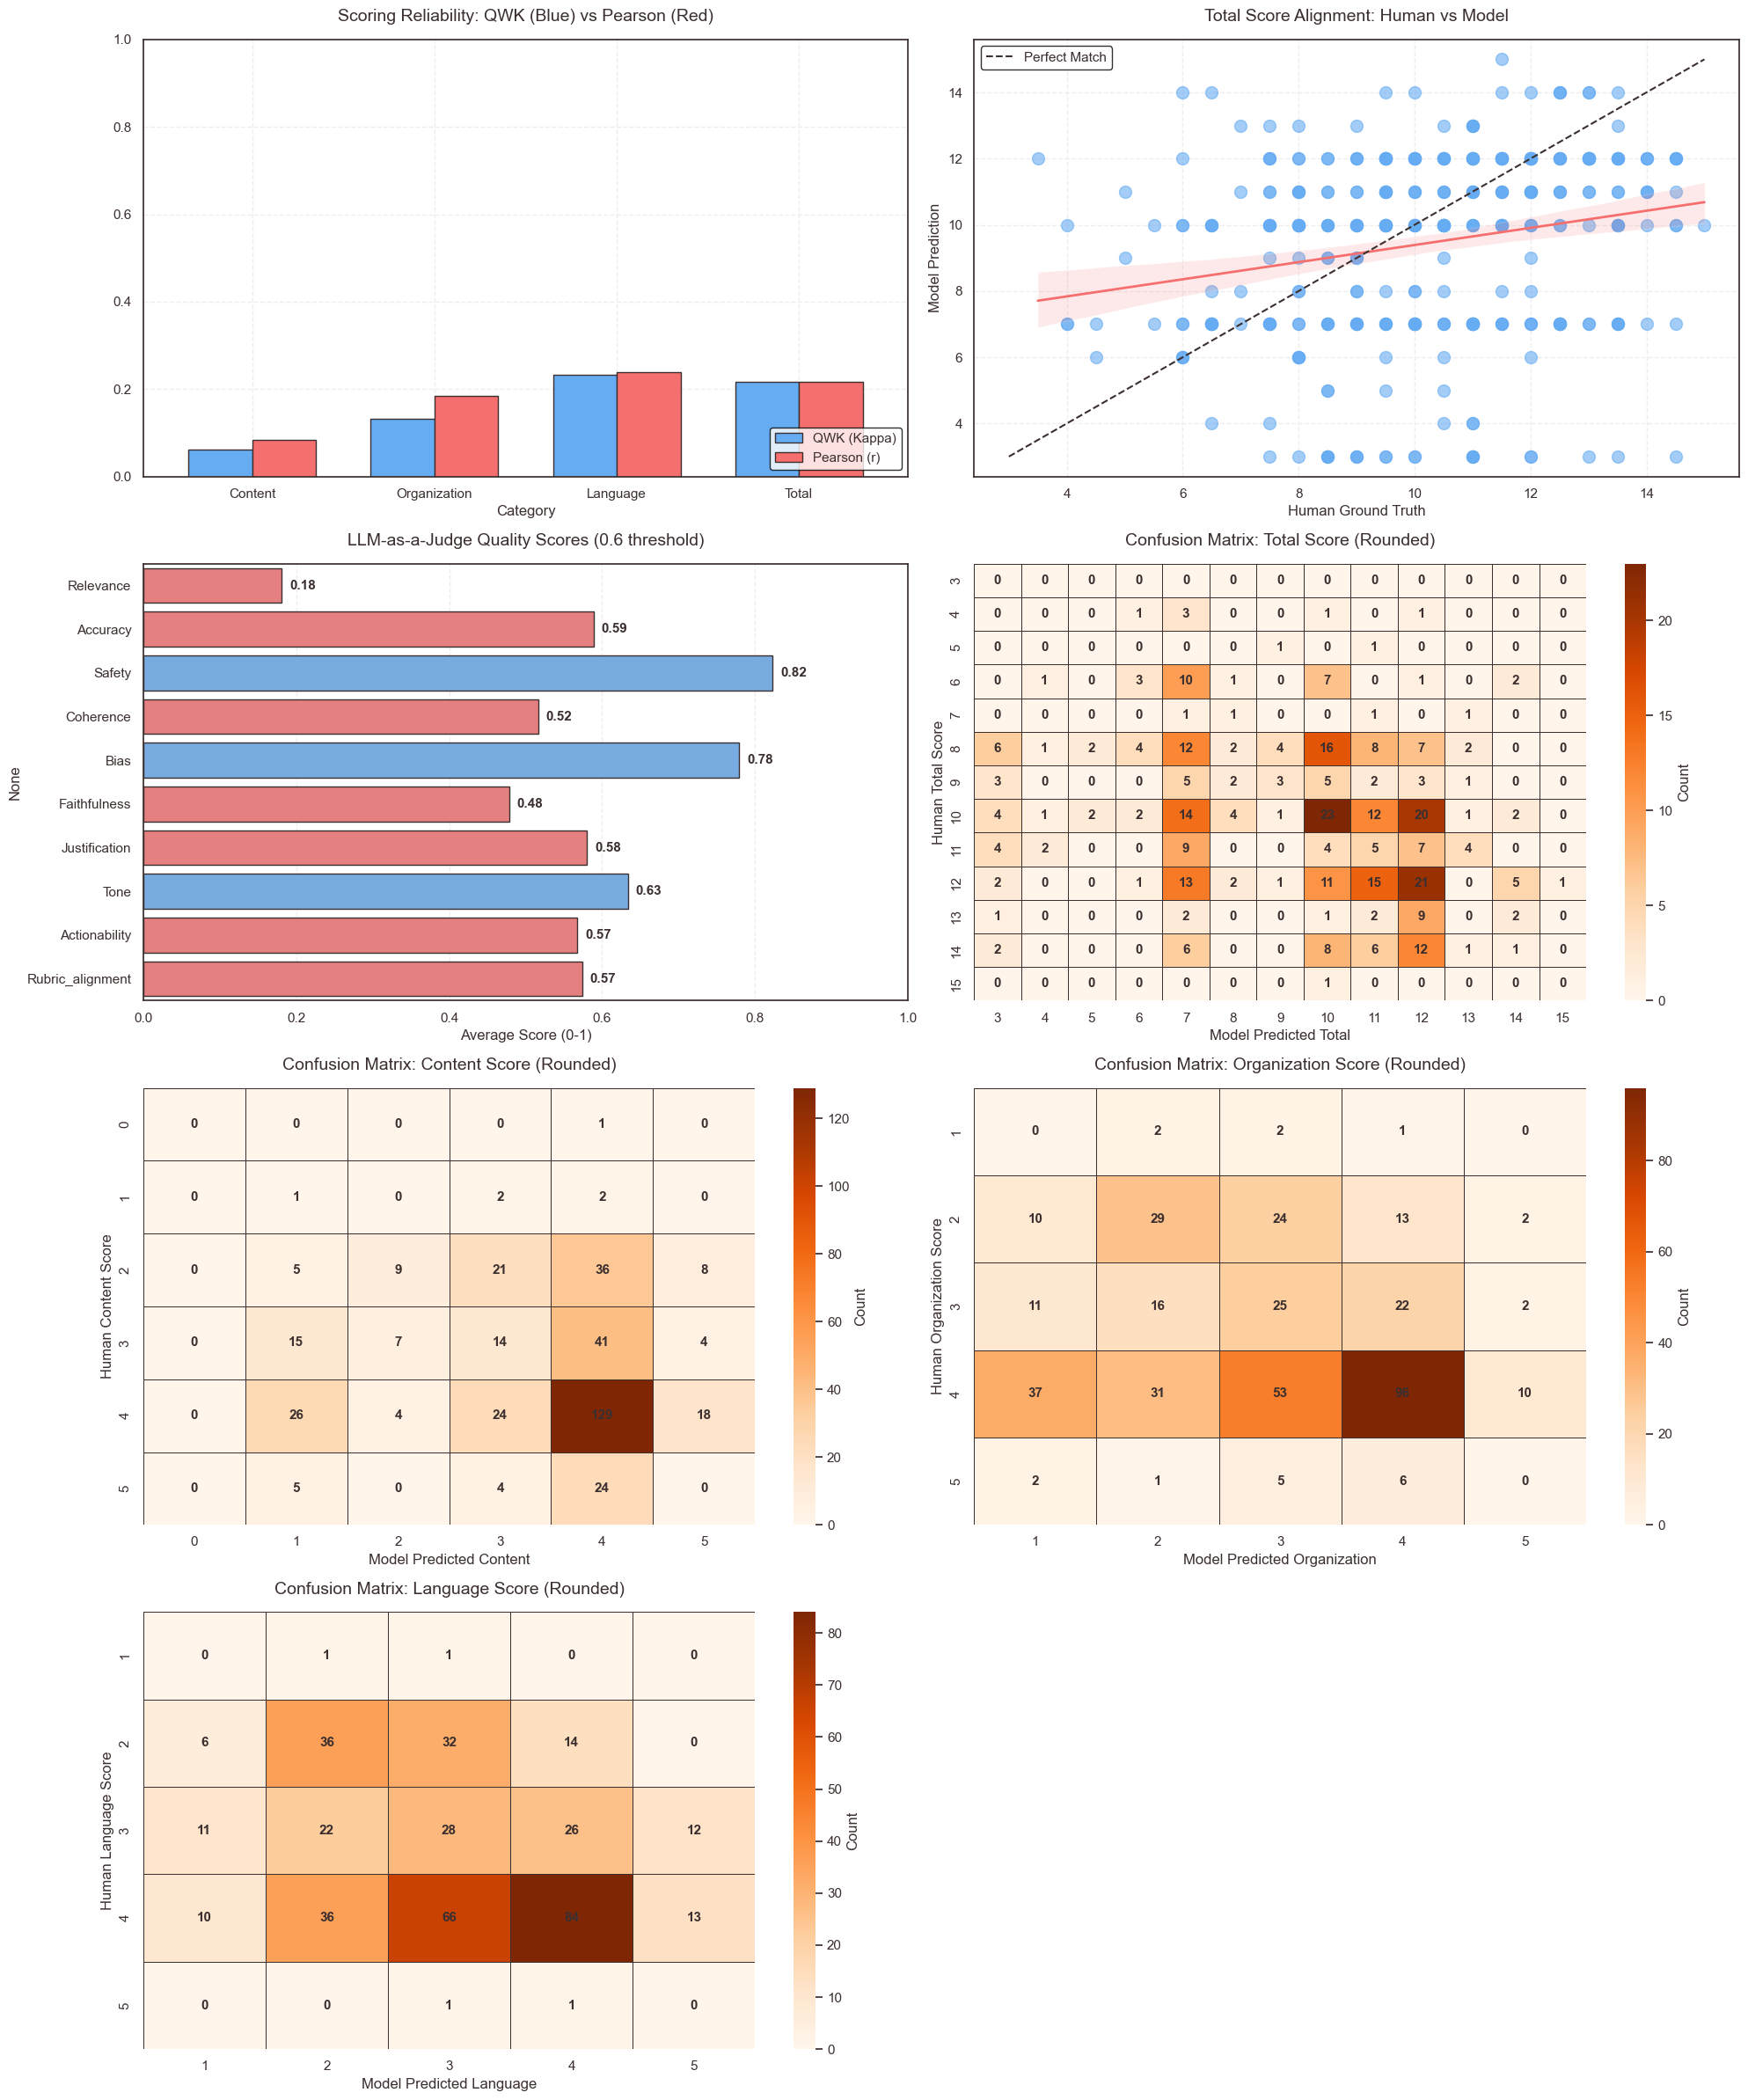


       QUALITATIVE ANALYSIS SAMPLE
Essay ID: 2247
Human Total: 10.5 | Model Total: 6.0
------------------------------------------------------------
[MODEL FEEDBACK]:
[Content]: The essay partially addresses the prompt but lacks depth and development. The student provides specific reasons and details to support their opinion, which is a strong point. However, the essay is disorganized, and the writer jumps between ideas without clear transitions. To improve, focus on developing a clear structure and connecting the ideas more logically.

[Organization]: The essay lacks a clear structure, and the writer fails to organize their ideas into a logical flow. The essay is a collection of disconnected sentences and ideas. To improve, use a clear introduction, body paragraphs, and a conclusion to guide the reader through the essay.

[Language]: The language is simple and repetitive. The writer uses short sentences and lacks variety in their vocabulary. For example, "I think it's taste, long open

In [2]:
import pandas as pd
df = pd.read_csv("/Users/matto/Documents/_Testing_evaluation/llm_evaluation/output/df_final_deepeval_qwen_results.csv")
try:
    generate_visualizations(df, config)
except Exception as e:
    print(f"Warning: failed to generate visualisations: {e}")

## Stage 8: LLM-Assisted Meta Analysis (optional)

**Goal:** have a larger “analyst” model read the summary metrics and produce an executive summary:
- key strengths
- critical weaknesses
- recommended next actions

**Why it’s optional:**
- It can be **memory-heavy** (a 20B GGUF for example)
- It is not required to validate the pipeline; it’s just a helpful reporting layer

**What happens:**
- `perform_meta_analysis` reads `metrics_summary.csv` and writes a report (implementation-dependent).

**Notes for reuse:**
- This stage should never be your *only* interpretation. Treat it as a draft to review.
- File: `meta_analysis.py`

In [8]:
from evaluation.meta_analysis import perform_meta_analysis

print(f"\n--- Starting Stage 8: Meta-Analysis ---")

# Free ram for the large meta-analysis model
cleanup(manager)

meta_conf = config.get("meta_analysis_model")
    
if meta_conf:
    print(f"Loading Analysis Model: {meta_conf['repo']}...")
    try:
            # Load the 20B model
        manager.load_model(
            repo_id=meta_conf["repo"],
            filename=meta_conf["file"]
        )
        print("Performing Meta-Analysis...")
        perform_meta_analysis(
            manager=manager, 
            config=config, 
            metrics_csv_path=summary_path, 
            output_dir=output_dir
        )
            
    except Exception as e:
        print(f"Skipping Meta-Analysis due to error (likely memory or download): {e}")
else:
    print("Warning: 'meta_analysis_model' not found in config. Skipping Stage 8.")

INFO:evaluation.cleanup:Deleting current model unsloth/Qwen2.5-VL-7B-Instruct-GGUF/Qwen2.5-VL-7B-Instruct-Q4_K_M.gguf…



--- Starting Stage 8: Meta-Analysis ---


INFO:evaluation.cleanup:Resources cleared.
INFO:evaluation.model_manager:Loading model: unsloth/gpt-oss-20b-GGUF (gpt-oss-20b-Q4_K_M.gguf)…


Loading Analysis Model: unsloth/gpt-oss-20b-GGUF...


llama_context: n_ctx_per_seq (8192) < n_ctx_train (131072) -- the full capacity of the model will not be utilized
ggml_metal_init: skipping kernel_get_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_set_rows_bf16                     (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_c4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_1row              (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_f32_l4                (not supported)
ggml_metal_init: skipping kernel_mul_mv_bf16_bf16                  (not supported)
ggml_metal_init: skipping kernel_mul_mv_id_bf16_f32                (not supported)
ggml_metal_init: skipping kernel_mul_mm_bf16_f32                   (not supported)
ggml_metal_init: skipping kernel_mul_mm_id_bf16_f16                (not supported)
ggml_metal_init: skipping kernel_flash_attn_ext_bf16_h64

Performing Meta-Analysis...

############################################################
          META-ANALYSIS (By Lead Data Scientist)
############################################################

# Executive Analysis of LLM-Based Essay Feedback System

## 1. Executive Summary  
The automated essay feedback system demonstrates **inadequate performance** in critical areas that directly impact grading accuracy and student support. While the model shows moderate semantic overlap with expert feedback (BERTScore F1 = 0.849) and maintains a low level of bias and safety, its **scoring reliability is essentially random** (overall correlation r = 0.22, agreement k = 0.22, MSE = 10.73). Additionally, the LLM-as-a-judge evaluation reveals **weaknesses across accuracy, coherence, faithfulness, and rubric alignment**, with a particularly alarming relevance score of 0.18. These deficiencies indicate that the system is **not ready for full deployment** and would likely mislead students and educat

## Stage 9: Cleanup (free RAM/VRAM)

This stage calls `cleanup(manager)` to unload any models that are still resident in memory.

Why this matters:
- GGUF models can hold large memory allocations.
- If you are iterating (changing prompts, rerunning inference), cleanup prevents “mysterious” OOM errors.

In [11]:
cleanup(manager)

INFO:evaluation.cleanup:Deleting current model unsloth/gpt-oss-20b-GGUF/gpt-oss-20b-Q4_K_M.gguf…
INFO:evaluation.cleanup:Resources cleared.
